# Data Understanding

Overview of the sales, store, and external feature datasets used for multi-store sales forecasting.

In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
def find_project_root():
    path = Path.cwd().resolve()

    for candidate in [path, *path.parents]:
        if (candidate / "data" / "raw").exists():
            return candidate

    raise FileNotFoundError("Project root not found")


PROJECT_ROOT = find_project_root()
RAW_DIR = PROJECT_ROOT / "data" / "raw"

In [4]:
train = pd.read_csv(RAW_DIR / "train.csv")
features = pd.read_csv(RAW_DIR / "features.csv")
stores = pd.read_csv(RAW_DIR / "stores.csv")
test = pd.read_csv(RAW_DIR / "test.csv")

## Dataset Overview

In [6]:
datasets = {
    "Train": train,
    "Features": features,
    "Stores": stores,
    "Test": test
}

pd.DataFrame(
    {name: [df.shape[0], df.shape[1]] for name, df in datasets.items()},
    index=["Rows", "Columns"]
).T

,Rows,Columns
Train,421570,5
Features,8190,12
Stores,45,3
Test,115064,4


In [7]:
pd.DataFrame({
    "Dataset": ["Train", "Features", "Stores", "Test"],
    "Key": [
        "Store + Dept + Date",
        "Store + Date",
        "Store",
        "Store + Dept + Date"
    ],
    "Target": [
        "Weekly_Sales",
        "—",
        "—",
        "—"
    ]
})

,Dataset,Key,Target
0,Train,Store + Dept + Date,Weekly_Sales
1,Features,Store + Date,—
2,Stores,Store,—
3,Test,Store + Dept + Date,—


## Data Types and Missing Values

In [9]:
train.dtypes.to_frame("Data Type")

,Data Type
Store,int64
Dept,int64
Date,str
Weekly_Sales,float64
IsHoliday,bool


In [10]:
missing = (
    features.isna()
    .sum()
    .to_frame("Missing")
)

missing["Missing %"] = missing["Missing"] / len(features) * 100

missing[missing["Missing"] > 0].sort_values(
    "Missing %", ascending=False
)

,Missing,Missing %
MarkDown2,5269,64.334554
MarkDown4,4726,57.704518
MarkDown3,4577,55.885226
MarkDown1,4158,50.769231
MarkDown5,4140,50.549451
CPI,585,7.142857
Unemployment,585,7.142857


## Data Integrity

In [12]:
train_key_dupes = train.duplicated(
    ["Store", "Dept", "Date"]
).sum()

features_key_dupes = features.duplicated(
    ["Store", "Date"]
).sum()

test_key_dupes = test.duplicated(
    ["Store", "Dept", "Date"]
).sum()

print("Train key duplicates:", train_key_dupes)
print("Features key duplicates:", features_key_dupes)
print("Test key duplicates:", test_key_dupes)

assert train_key_dupes == 0
assert features_key_dupes == 0
assert test_key_dupes == 0

Train key duplicates: 0
Features key duplicates: 0
Test key duplicates: 0


In [13]:
missing_summary = (
    features.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("Missing")
)

missing_summary["Missing %"] = (
    missing_summary["Missing"] / len(features) * 100
)

display(missing_summary)

,Missing,Missing %
MarkDown2,5269,64.334554
MarkDown4,4726,57.704518
MarkDown3,4577,55.885226
MarkDown1,4158,50.769231
MarkDown5,4140,50.549451
CPI,585,7.142857
Unemployment,585,7.142857
Store,0,0.000000
Fuel_Price,0,0.000000
Temperature,0,0.000000


## Sales Coverage

In [15]:
train["Date"] = pd.to_datetime(train["Date"])
features["Date"] = pd.to_datetime(features["Date"])
test["Date"] = pd.to_datetime(test["Date"])

print("Train:", train["Date"].min().date(), "to", train["Date"].max().date())
print("Test:", test["Date"].min().date(), "to", test["Date"].max().date())
print("Stores:", train["Store"].nunique())
print("Departments:", train["Dept"].nunique())

Train: 2010-02-05 to 2012-10-26
Test: 2012-11-02 to 2013-07-26
Stores: 45
Departments: 81


In [16]:
train["Weekly_Sales"].describe().to_frame("Weekly Sales")

,Weekly Sales
count,421570.000000
mean,15981.258123
std,22711.183519
min,-4988.940000
25%,2079.650000
50%,7612.030000
75%,20205.852500
max,693099.360000


In [17]:
print("Negative sales:", (train["Weekly_Sales"] < 0).sum())
print("Zero sales:", (train["Weekly_Sales"] == 0).sum())

Negative sales: 1285
Zero sales: 73


## Store Structure

In [19]:
stores["Type"].value_counts().sort_index().to_frame("Stores")

,Stores
Type,
A,22
B,17
C,6


In [20]:
stores["Size"].describe().to_frame("Store Size")

,Store Size
count,45.000000
mean,130287.600000
std,63825.271991
min,34875.000000
25%,70713.000000
50%,126512.000000
75%,202307.000000
max,219622.000000


## Sales Distribution

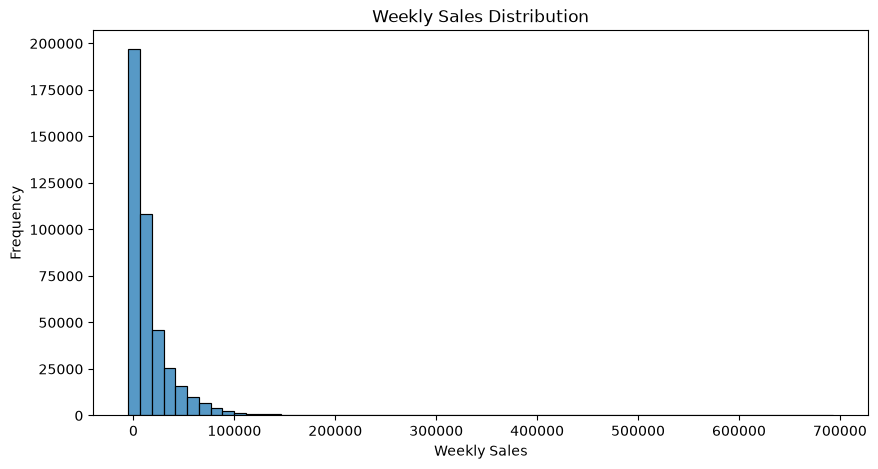

In [22]:
plt.figure(figsize=(10, 5))
sns.histplot(train["Weekly_Sales"], bins=60)
plt.title("Weekly Sales Distribution")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")
plt.show()

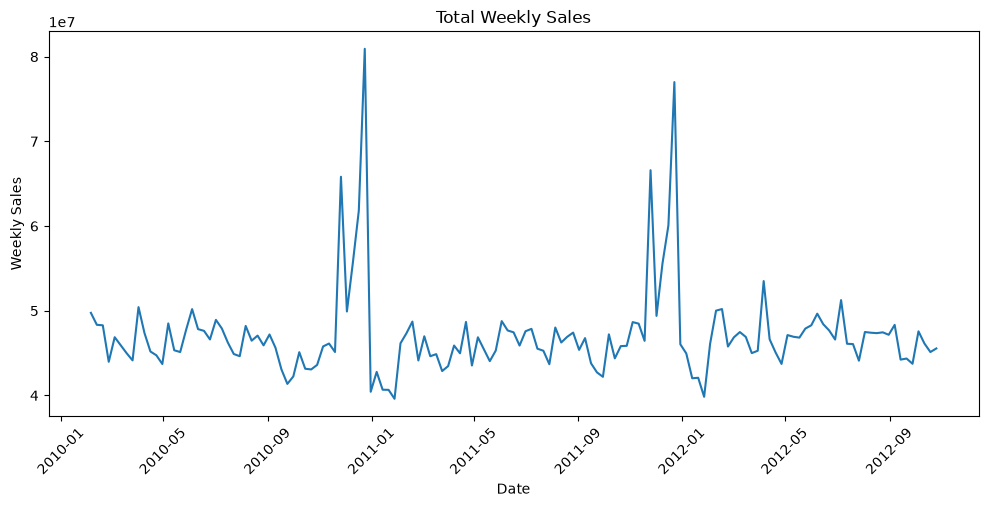

In [23]:
weekly_sales = (
    train.groupby("Date", as_index=False)["Weekly_Sales"]
    .sum()
)

plt.figure(figsize=(12, 5))
plt.plot(weekly_sales["Date"], weekly_sales["Weekly_Sales"])
plt.title("Total Weekly Sales")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.xticks(rotation=45)
plt.show()

In [24]:
assert train["Date"].max() < test["Date"].min()

print("Train/Test overlap:",
      len(set(train["Date"]) & set(test["Date"])))

print("Temporal separation: confirmed")

Train/Test overlap: 0
Temporal separation: confirmed


## Key Findings

- The training data contains 421,570 store-department observations across 45 stores and 81 departments.
- Training covers February 2010 to October 2012, while the test period begins in November 2012.
- The external feature dataset contains substantial missingness in MarkDown variables and limited missingness in CPI and Unemployment.
- The sales target contains both negative and zero observations; these are retained for downstream investigation.
- Store metadata provides Type and Size variables for modeling.